In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("screen_time.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   User_ID    Device_Model Operating_System  App_Usage_Time  Screen_On_Time  \
0        1  Google Pixel 5          Android             393             6.4   
1        2       OnePlus 9          Android             268             4.7   
2        3    Xiaomi Mi 11          Android             154             4.0   
3        4  Google Pixel 5          Android             239             4.8   
4        5       iPhone 12              iOS             187             4.3   

   Battery_Drain  Number_of_Apps_Installed  Data_Usage  Age  Gender  \
0           1872                        67        1122   40    Male   
1           1331                        42         944   47  Female   
2            761                        32         322   42    Male   
3           1676                        56         871   20    Male   
4           1367                        58         988   31  Female   

   User_Behavior_Class  
0                    4  
1                  

In [12]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (700, 11)

Column Names:
['User_ID', 'Device_Model', 'Operating_System', 'App_Usage_Time', 'Screen_On_Time', 'Battery_Drain', 'Number_of_Apps_Installed', 'Data_Usage', 'Age', 'Gender', 'User_Behavior_Class']

Missing Values:
User_ID                     0
Device_Model                0
Operating_System            0
App_Usage_Time              0
Screen_On_Time              0
Battery_Drain               0
Number_of_Apps_Installed    0
Data_Usage                  0
Age                         0
Gender                      0
User_Behavior_Class         0
dtype: int64


In [13]:
df = df.dropna()

print("After removing missing values:")
print(df.shape)

After removing missing values:
(700, 11)


In [16]:
X = df[['App_Usage_Time',
        'Battery_Drain',
        'Number_of_Apps_Installed',
        'Data_Usage',
        'Age']]

y = df['Screen_On_Time']

print("Input Features:")
print(X.head())

print("\nTarget - Screen On Time:")
print(y.head())

Input Features:
   App_Usage_Time  Battery_Drain  Number_of_Apps_Installed  Data_Usage  Age
0             393           1872                        67        1122   40
1             268           1331                        42         944   47
2             154            761                        32         322   42
3             239           1676                        56         871   20
4             187           1367                        58         988   31

Target - Screen On Time:
0    6.4
1    4.7
2    4.0
3    4.8
4    4.3
Name: Screen_On_Time, dtype: float64


In [15]:
print(df.columns.tolist())


['User_ID', 'Device_Model', 'Operating_System', 'App_Usage_Time', 'Screen_On_Time', 'Battery_Drain', 'Number_of_Apps_Installed', 'Data_Usage', 'Age', 'Gender', 'User_Behavior_Class']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (560, 5)
Testing data: (140, 5)


In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [19]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[ 6.5  1.3  1.1  3.4  6.   3.4  3.8  1.2  6.5  4.1  1.6  1.6  2.8  1.8
  4.3  7.1  8.8  2.   5.2  3.6 11.8  6.1  4.2  7.6  6.9  3.8  4.3  8.7
  4.  10.7  1.   4.7  1.7  6.   6.4 10.4 11.6  1.6  1.2  3.6  5.4  6.3
  1.2  6.   2.  10.8  5.5  4.6  2.   4.2  3.3  2.1  2.5  1.4 11.5 10.7
  4.5  1.6  7.7  2.4  4.6  2.4  1.1  2.5 11.4  4.  10.9  1.6 11.3 11.2
  1.   4.   5.2  2.8  5.   3.9 10.8  6.   6.6  7.2  3.3  1.3  6.3  4.2
  7.2  7.6 11.9  4.2  6.   1.7  1.2  7.9  2.4  5.   7.2  3.8  3.7  1.9
  4.6  8.4  4.6  4.8  1.4  1.3  4.   6.9  8.7  1.6  7.2  6.2  9.   6.1
  7.3  4.1  5.5  3.3  6.8  5.7  6.6  5.3  4.4  7.5  9.3  6.8 10.4  2.4
  5.1 11.1  6.6 10.1  5.5  4.   1.1  5.   2.2  4.   9.6  3.8  1.7  3.8]

Predicted Values:
[ 7.66737192  1.42451298  1.44537628  3.23169838  5.15057673  2.90691097
  2.84960171  1.4898815   7.26972143  5.23754803  1.65129799  1.61069936
  3.00255864  1.55939108  4.58163691  7.68010451  9.24506258  1.18871401
  4.98320402  3.09241727  9.58027448

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("----------------------------")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Model Performance
----------------------------
Mean Absolute Error: 0.6618108529543264
Mean Squared Error: 0.6871683952631022
R2 Score: 0.9234133160167306


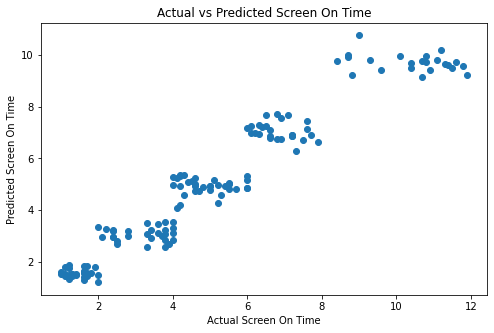

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Screen On Time")
plt.ylabel("Predicted Screen On Time")
plt.title("Actual vs Predicted Screen On Time")

plt.show()